In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy import ndimage
import time
import os

📝 Создаём изображение для Watershed...
📝 Создаём изображение для GrabCut...


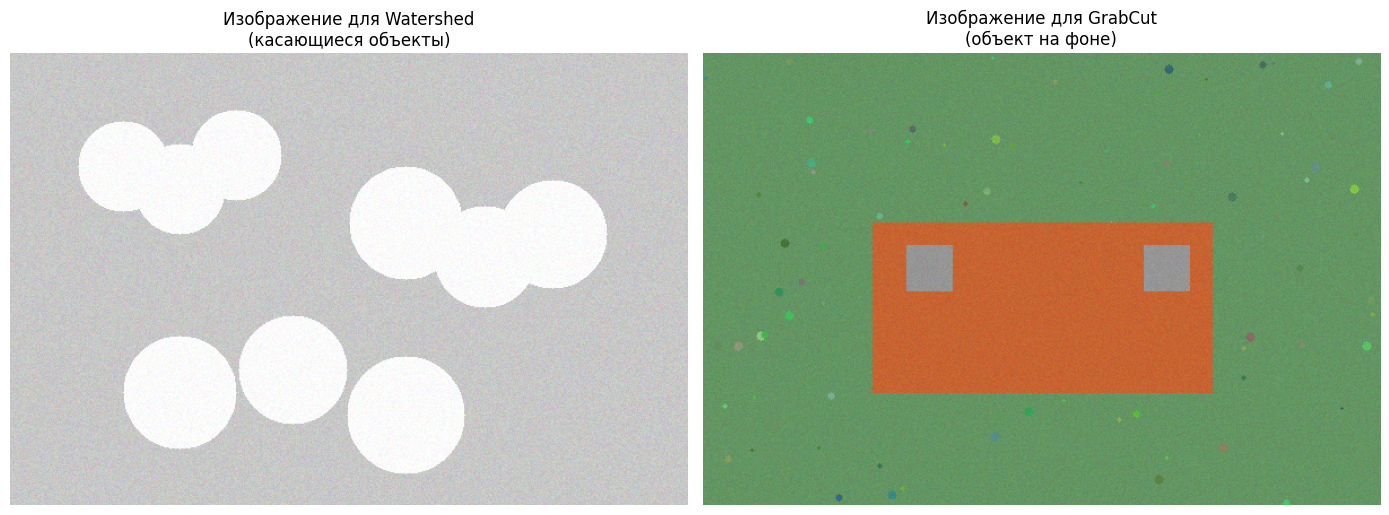

In [2]:
# ===============================
# Создание тестовых изображений
# ===============================

def create_watershed_test_image():
    """Создаёт изображение с касающимися объектами для Watershed"""

    print("📝 Создаём изображение для Watershed...")

    # Фон
    img = np.ones((400, 600, 3), dtype=np.uint8) * 200

    # Несколько "монет" (белых кругов) на сером фоне
    cv2.circle(img, (100, 100), 40, (255, 255, 255), -1)
    cv2.circle(img, (150, 120), 40, (255, 255, 255), -1)
    cv2.circle(img, (200, 90), 40, (255, 255, 255), -1)

    cv2.circle(img, (350, 150), 50, (255, 255, 255), -1)
    cv2.circle(img, (420, 180), 45, (255, 255, 255), -1)
    cv2.circle(img, (480, 160), 48, (255, 255, 255), -1)

    cv2.circle(img, (150, 300), 50, (255, 255, 255), -1)
    cv2.circle(img, (250, 280), 48, (255, 255, 255), -1)
    cv2.circle(img, (350, 320), 52, (255, 255, 255), -1)

    # Добавляем шум
    noise = np.random.randint(-15, 15, img.shape, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img

def create_grabcut_test_image():
    """Создаёт изображение для GrabCut (объект на фоне)"""

    print("📝 Создаём изображение для GrabCut...")

    # Фон - зелёный природный
    img = np.ones((400, 600, 3), dtype=np.uint8) * 100
    img[:, :] = [100, 150, 100]  # Зелёный фон

    # Добавляем текстуру фона
    for _ in range(100):
        x, y = np.random.randint(0, 600), np.random.randint(0, 400)
        cv2.circle(img, (x, y), np.random.randint(1, 5),
                  (np.random.randint(50, 150), np.random.randint(100, 200),
                   np.random.randint(50, 150)), -1)

    # Объект в центре (красная машина - прямоугольник)
    cv2.rectangle(img, (150, 150), (450, 300), (50, 100, 200), -1)

    # Окна
    cv2.rectangle(img, (180, 170), (220, 210), (150, 150, 150), -1)
    cv2.rectangle(img, (390, 170), (430, 210), (150, 150, 150), -1)

    # Добавляем шум
    noise = np.random.randint(-10, 10, img.shape, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img

# Создаём изображения
watershed_img = create_watershed_test_image()
grabcut_img = create_grabcut_test_image()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(cv2.cvtColor(watershed_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Изображение для Watershed\n(касающиеся объекты)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(grabcut_img, cv2.COLOR_BGR2RGB))
axes[1].set_title('Изображение для GrabCut\n(объект на фоне)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Маркер-управляемая сегментация Watershed
Устанавливаем маркеры объектов...
Устанавливаем маркеры фона...
Применяем Watershed алгоритм...


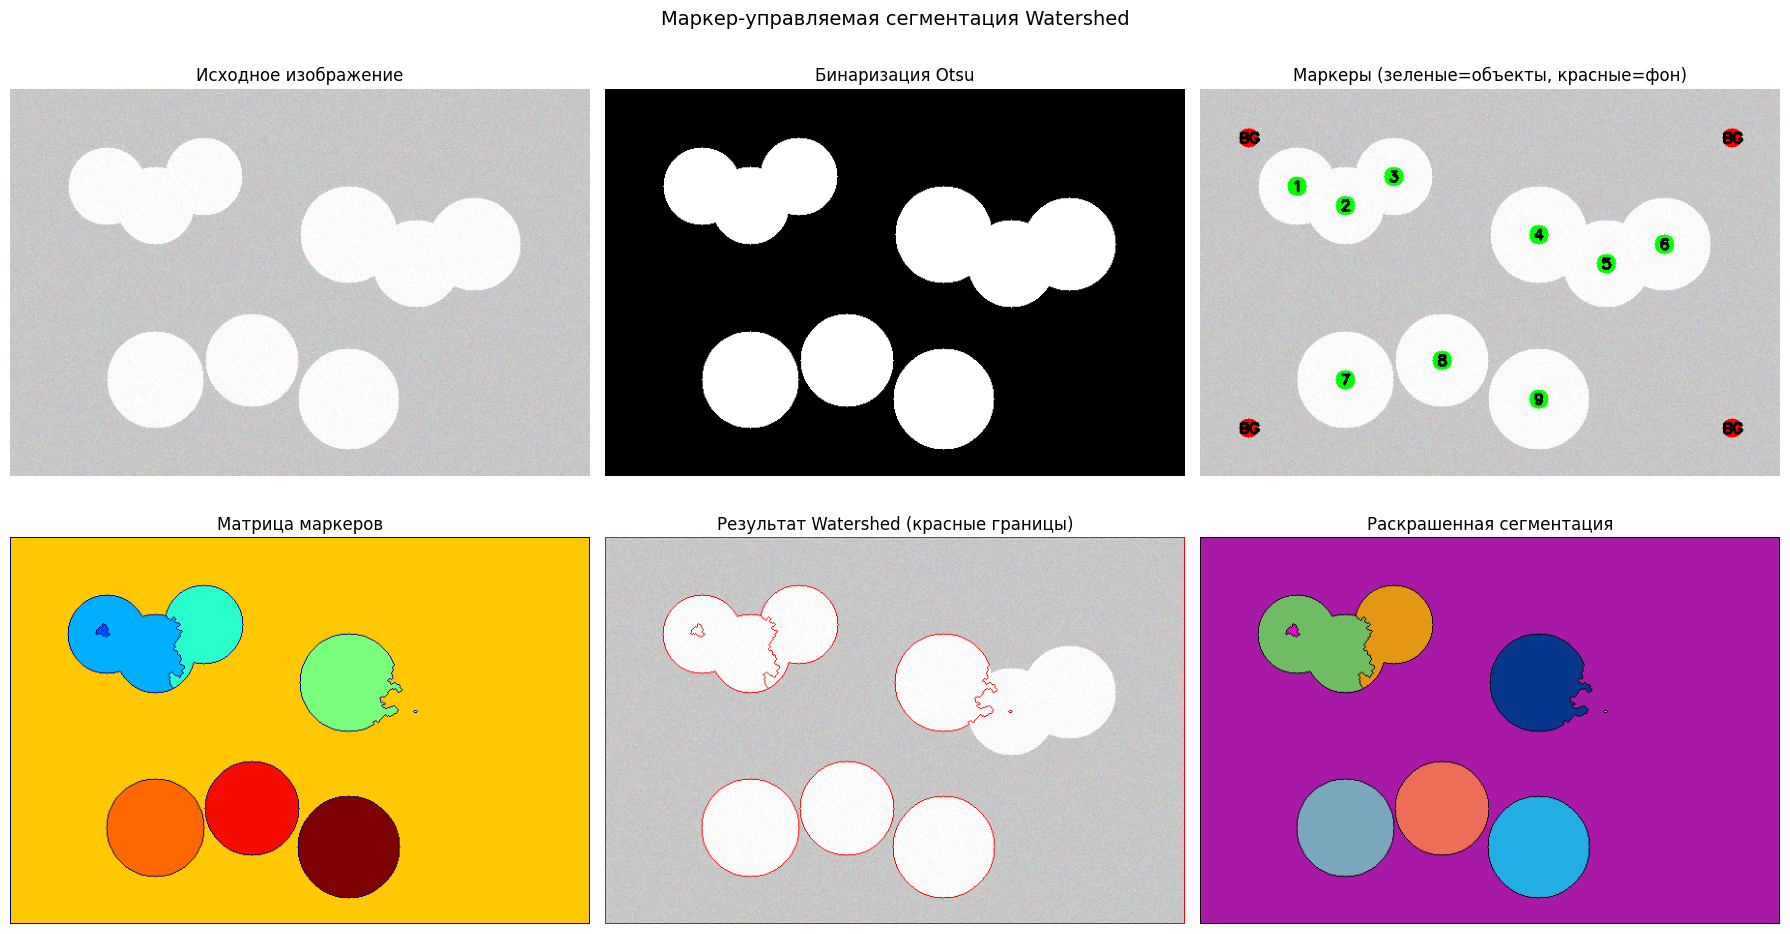

Найдено сегментов: 9
Уникальные маркеры: [-1  1  2  3  4  5  6  7  8  9]


In [4]:
# ===============================
# ЗАДАНИЕ 1: Маркер-управляемая сегментация
# ===============================

def manual_marker_segmentation(img):
    """
    Маркер-управляемая сегментация с использованием Watershed
    """
    print("Маркер-управляемая сегментация Watershed")
    print("="*60)

    # Создаем копию изображения для рисования маркеров
    img_markers = img.copy()
    markers_viz = img.copy()

    # Преобразуем в grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Применяем бинаризацию Otsu
    ret, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Создаем маску для маркеров (изначально все - фон)
    markers = np.zeros(img.shape[:2], dtype=np.int32)

    # Предопределенные маркеры для демонстрации
    # В реальном приложении пользователь бы рисовал их вручную

    # Маркеры для объектов (положительные значения)
    object_markers = [
        (100, 100),  # Объект 1
        (150, 120),  # Объект 2
        (200, 90),   # Объект 3
        (350, 150),  # Объект 4
        (420, 180),  # Объект 5
        (480, 160),  # Объект 6
        (150, 300),  # Объект 7
        (250, 280),  # Объект 8
        (350, 320),  # Объект 9
    ]

    # Маркеры для фона (отрицательные значения)
    background_markers = [
        (50, 50),    # Фон 1
        (550, 50),   # Фон 2
        (50, 350),   # Фон 3
        (550, 350),  # Фон 4
    ]

    # Рисуем маркеры объектов (белые круги)
    print("Устанавливаем маркеры объектов...")
    for i, (x, y) in enumerate(object_markers, start=1):
        # Устанавливаем маркер
        markers[y, x] = i

        # Рисуем маркер на визуализации
        cv2.circle(img_markers, (x, y), 10, (0, 255, 0), -1)  # Зеленый для объектов
        cv2.circle(markers_viz, (x, y), 10, (0, 255, 0), -1)
        cv2.putText(markers_viz, str(i), (x-5, y+5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

    # Рисуем маркеры фона (красные круги)
    print("Устанавливаем маркеры фона...")
    for i, (x, y) in enumerate(background_markers, start=1):
        # Устанавливаем маркер фона как 0 (фон)
        markers[y, x] = 0

        # Рисуем маркер на визуализации
        cv2.circle(img_markers, (x, y), 10, (0, 0, 255), -1)  # Красный для фона
        cv2.circle(markers_viz, (x, y), 10, (0, 0, 255), -1)
        cv2.putText(markers_viz, "BG", (x-10, y+5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

    # Применяем Watershed с маркерами
    print("Применяем Watershed алгоритм...")
    markers = cv2.watershed(img, markers)

    # Создаем результат с границами
    result = img.copy()
    result[markers == -1] = [0, 0, 255]  # Красные границы

    # Создаем раскрашенную версию сегментации
    colored_segmentation = np.zeros_like(img)

    # Генерируем случайные цвета для сегментов
    unique_markers = np.unique(markers)
    colors = {}

    for marker in unique_markers:
        if marker > 0:  # Игнорируем фон и границы
            colors[marker] = np.random.randint(0, 255, 3).tolist()

    # Раскрашиваем сегменты
    for marker in unique_markers:
        if marker > 0:
            colored_segmentation[markers == marker] = colors[marker]

    # Визуализация результатов
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Исходное изображение')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(binary, cmap='gray')
    axes[0, 1].set_title('Бинаризация Otsu')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(cv2.cvtColor(markers_viz, cv2.COLOR_BGR2RGB))
    axes[0, 2].set_title('Маркеры (зеленые=объекты, красные=фон)')
    axes[0, 2].axis('off')

    # Визуализация матрицы маркеров
    markers_display = markers.copy()
    markers_display = markers_display.astype(np.float32)
    markers_display = cv2.normalize(markers_display, None, 0, 255, cv2.NORM_MINMAX)
    markers_display = markers_display.astype(np.uint8)

    axes[1, 0].imshow(markers_display, cmap='jet')
    axes[1, 0].set_title('Матрица маркеров')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title('Результат Watershed (красные границы)')
    axes[1, 1].axis('off')

    axes[1, 2].imshow(cv2.cvtColor(colored_segmentation, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title('Раскрашенная сегментация')
    axes[1, 2].axis('off')

    plt.suptitle('Маркер-управляемая сегментация Watershed', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Статистика
    n_segments = len([m for m in unique_markers if m > 0])
    print(f"Найдено сегментов: {n_segments}")
    print(f"Уникальные маркеры: {unique_markers}")

    return result, colored_segmentation, markers

# Применяем маркер-управляемую сегментацию
result_manual, colored_manual, markers_manual = manual_marker_segmentation(watershed_img)

📝 Создаём изображение для GrabCut...
Улучшенный GrabCut с штрихами
Инициализация с прямоугольником завершена
Размер маски: (400, 600)
Применяем штрихи для уточнения...
Итеративное уточнение с штрихами завершено
Пикселей переднего плана: 1343 (0.6%)
Пикселей заднего плана: 238657 (99.4%)


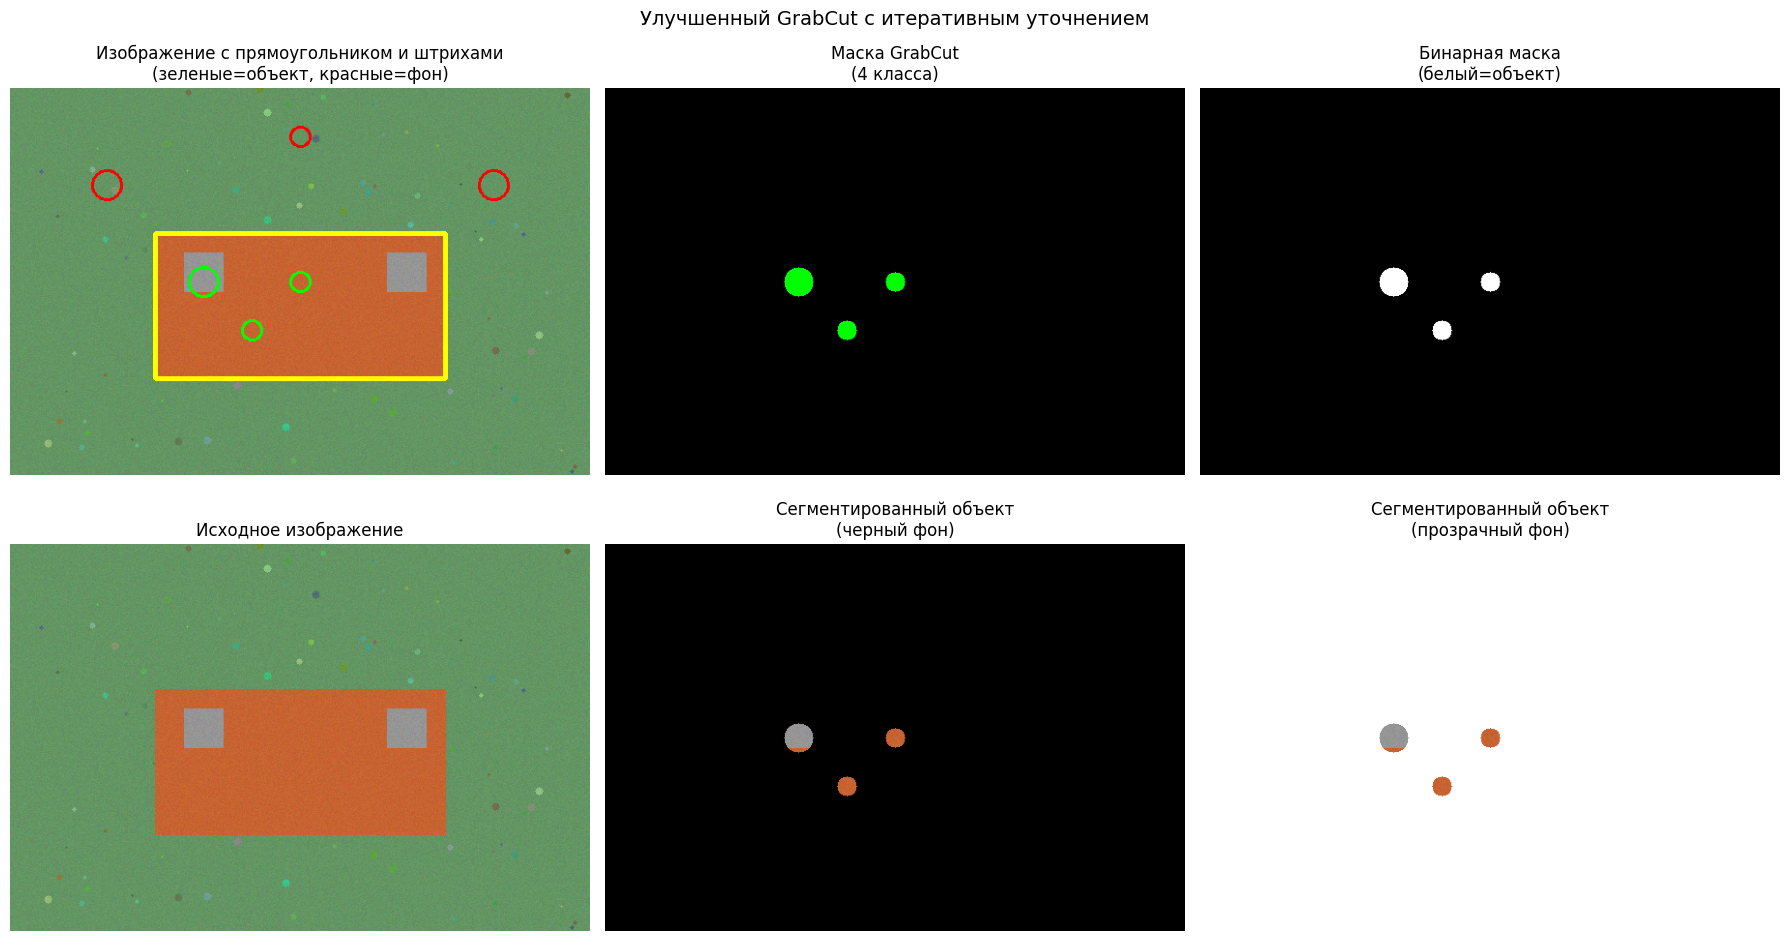


Демонстрация итеративного уточнения...


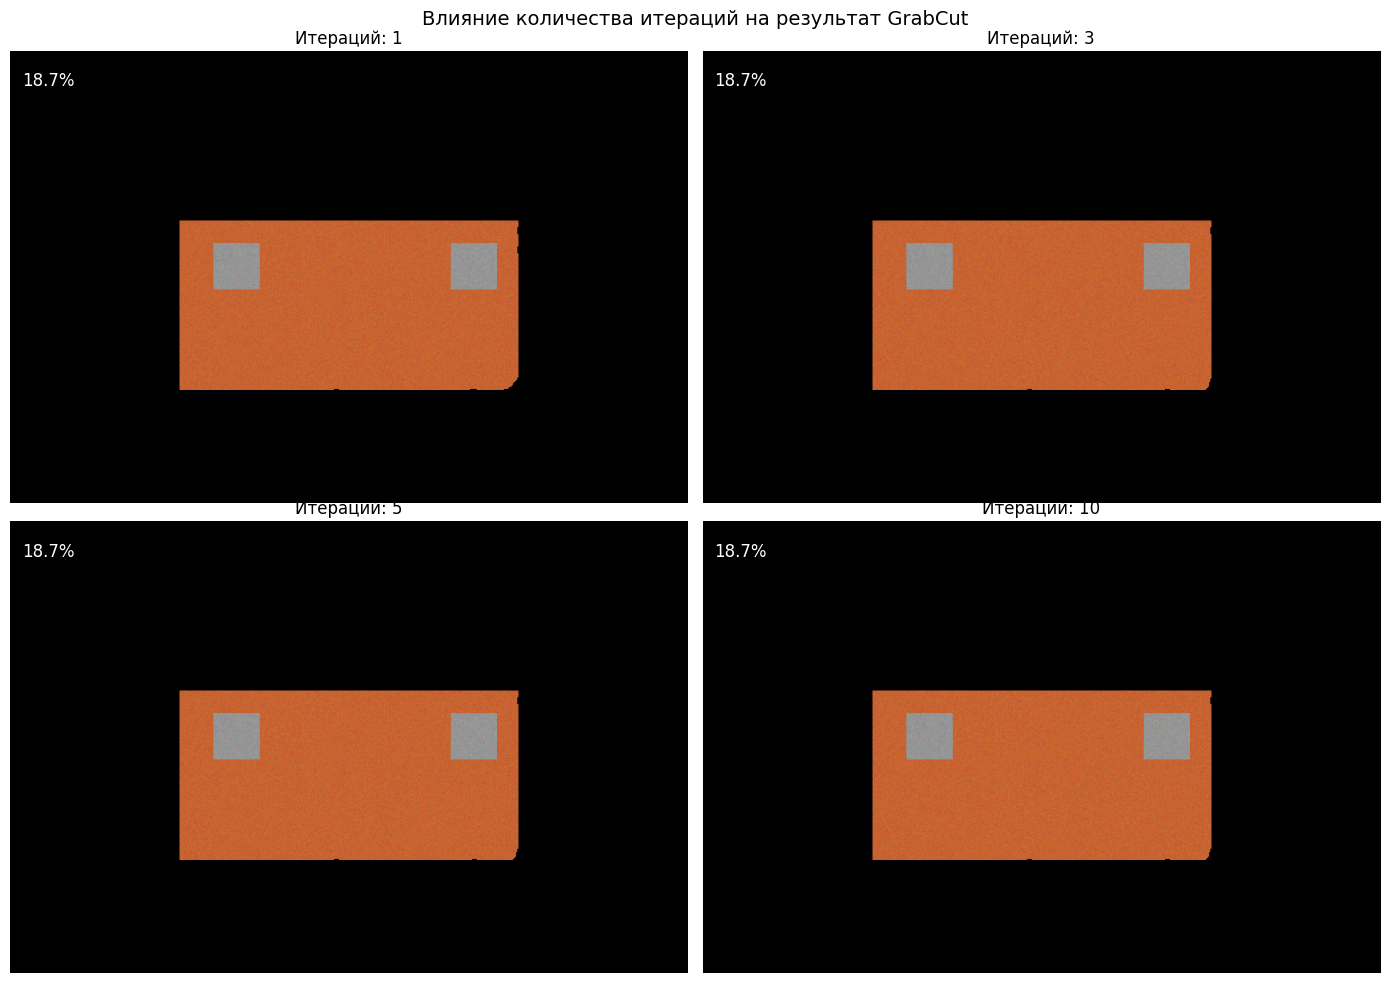

In [6]:
# ===============================
# ЗАДАНИЕ 2: Улучшение GrabCut
# ===============================

def improved_grabcut_segmentation(img, rect,
                                  foreground_strokes=None,
                                  background_strokes=None,
                                  max_iterations=10):

    print("Улучшенный GrabCut с штрихами")
    print("="*60)

    # Создаем копию изображения для визуализации
    img_viz = img.copy()
    x, y, w, h = rect

    # Рисуем ограничивающий прямоугольник
    cv2.rectangle(img_viz, (x, y), (x+w, y+h), (0, 255, 255), 3)

    # Инициализируем маску
    mask = np.zeros(img.shape[:2], dtype=np.uint8)

    # Инициализируем модели
    bgd_model = np.zeros((1, 65), dtype=np.float64)
    fgd_model = np.zeros((1, 65), dtype=np.float64)

    # Начальная инициализация с прямоугольником
    cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

    print(f"Инициализация с прямоугольником завершена")
    print(f"Размер маски: {mask.shape}")

    # Если заданы штрихи, применяем их
    if foreground_strokes is not None or background_strokes is not None:
        print("Применяем штрихи для уточнения...")

        # Создаем маску для штрихов
        strokes_mask = np.zeros_like(mask)

        # Применяем штрихи переднего плана
        if foreground_strokes:
            for (sx, sy, radius) in foreground_strokes:
                cv2.circle(strokes_mask, (sx, sy), radius, 1, -1)  # Определенно передний план
                cv2.circle(img_viz, (sx, sy), radius, (0, 255, 0), 2)  # Зеленый для переднего плана

        # Применяем штрихи заднего плана
        if background_strokes:
            for (sx, sy, radius) in background_strokes:
                cv2.circle(strokes_mask, (sx, sy), radius, 0, -1)  # Определенно задний план
                cv2.circle(img_viz, (sx, sy), radius, (0, 0, 255), 2)  # Красный для заднего плана

        # Обновляем маску с учетом штрихов
        mask[strokes_mask == 1] = cv2.GC_FGD      # Определенно передний план
        mask[strokes_mask == 0] = cv2.GC_BGD      # Определенно задний план

        # Применяем GrabCut с инициализацией по маске
        cv2.grabCut(img, mask, rect, bgd_model, fgd_model,
                   max_iterations, cv2.GC_INIT_WITH_MASK)

        print("Итеративное уточнение с штрихами завершено")

    # Создаем финальную бинарную маску
    mask_binary = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)

    # Применяем маску к изображению
    result = img.copy()
    result = result * mask_binary[:, :, np.newaxis]

    # Альтернативно: делаем фон прозрачным
    result_with_alpha = cv2.cvtColor(img, cv2.COLOR_BGR2BGRA)
    result_with_alpha[:, :, 3] = mask_binary * 255

    # Создаем визуализацию маски
    mask_display = np.zeros_like(img)
    mask_display[mask == cv2.GC_BGD] = [0, 0, 0]        # Черный - определенно фон
    mask_display[mask == cv2.GC_FGD] = [0, 255, 0]      # Зеленый - определенно объект
    mask_display[mask == cv2.GC_PR_BGD] = [128, 0, 0]   # Темно-красный - вероятно фон
    mask_display[mask == cv2.GC_PR_FGD] = [0, 128, 0]   # Темно-зеленый - вероятно объект

    # Статистика
    n_foreground = np.sum(mask_binary)
    n_background = mask_binary.size - n_foreground
    print(f"Пикселей переднего плана: {n_foreground} ({n_foreground/mask_binary.size*100:.1f}%)")
    print(f"Пикселей заднего плана: {n_background} ({n_background/mask_binary.size*100:.1f}%)")

    return result, result_with_alpha, mask, mask_binary, mask_display, img_viz


# Создаем тестовое изображение для GrabCut
grabcut_demo_img = create_grabcut_test_image()

# Определяем ограничивающий прямоугольник
rect = (150, 150, 300, 150)  # (x, y, width, height)

# Определяем штрихи для уточнения
# Каждый штрих: (x, y, radius)
foreground_strokes = [
    (200, 200, 15),  # Центр машины
    (300, 200, 10),  # Правая часть машины
    (250, 250, 10),  # Нижняя часть машины
]

background_strokes = [
    (100, 100, 15),   # Верхний левый угол (фон)
    (500, 100, 15),   # Верхний правый угол (фон)
    (300, 50, 10),    # Верхний центр (фон)
]

# Применяем улучшенный GrabCut
result_grabcut, result_alpha, mask_grabcut, mask_binary_grabcut, mask_display_grabcut, img_viz = improved_grabcut_segmentation(
    grabcut_demo_img, rect, foreground_strokes, background_strokes, max_iterations=5
)

# Визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].imshow(cv2.cvtColor(img_viz, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Изображение с прямоугольником и штрихами\n(зеленые=объект, красные=фон)')
axes[0, 0].axis('off')

axes[0, 1].imshow(mask_display_grabcut)
axes[0, 1].set_title('Маска GrabCut\n(4 класса)')
axes[0, 1].axis('off')

axes[0, 2].imshow(mask_binary_grabcut, cmap='gray')
axes[0, 2].set_title('Бинарная маска\n(белый=объект)')
axes[0, 2].axis('off')

axes[1, 0].imshow(cv2.cvtColor(grabcut_demo_img, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Исходное изображение')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(result_grabcut, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Сегментированный объект\n(черный фон)')
axes[1, 1].axis('off')

# Для визуализации с альфа-каналом нам нужно преобразование
axes[1, 2].imshow(cv2.cvtColor(result_alpha, cv2.COLOR_BGRA2RGBA))
axes[1, 2].set_title('Сегментированный объект\n(прозрачный фон)')
axes[1, 2].axis('off')

plt.suptitle('Улучшенный GrabCut с итеративным уточнением', fontsize=14)
plt.tight_layout()
plt.show()

# Демонстрация итеративного уточнения
print("\nДемонстрация итеративного уточнения...")

# Создаем простую версию для демонстрации итераций
def iterative_grabcut_demo(img, rect, iterations_list=[1, 3, 5, 10]):
    """
    Демонстрация итеративного уточнения GrabCut
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, iterations in enumerate(iterations_list):
        # Инициализируем модели
        bgd_model = np.zeros((1, 65), dtype=np.float64)
        fgd_model = np.zeros((1, 65), dtype=np.float64)
        mask = np.zeros(img.shape[:2], dtype=np.uint8)

        # Применяем GrabCut
        cv2.grabCut(img, mask, rect, bgd_model, fgd_model, iterations, cv2.GC_INIT_WITH_RECT)

        # Создаем бинарную маску
        mask_binary = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)

        # Применяем маску
        result = img.copy()
        result = result * mask_binary[:, :, np.newaxis]

        # Визуализируем
        axes[idx].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
        axes[idx].set_title(f'Итераций: {iterations}')
        axes[idx].axis('off')

        # Вычисляем статистику
        n_foreground = np.sum(mask_binary)
        percentage = n_foreground / mask_binary.size * 100
        axes[idx].text(10, 30, f'{percentage:.1f}%', color='white',
                      fontsize=12, bbox=dict(facecolor='black', alpha=0.7))

    plt.suptitle('Влияние количества итераций на результат GrabCut', fontsize=14)
    plt.tight_layout()
    plt.show()

# Запускаем демонстрацию
iterative_grabcut_demo(grabcut_demo_img, rect)

📝 Создаём изображение для Watershed...
1. Предварительная обработка...
2. Пороговая фильтрация...
3. Морфологические операции...
4. Watershed для разделения объектов...
5. Постобработка...
   Удаление малых объектов...
Объектов до фильтрации: 11
Объектов после фильтрации: 12
Удалено малых объектов: -1


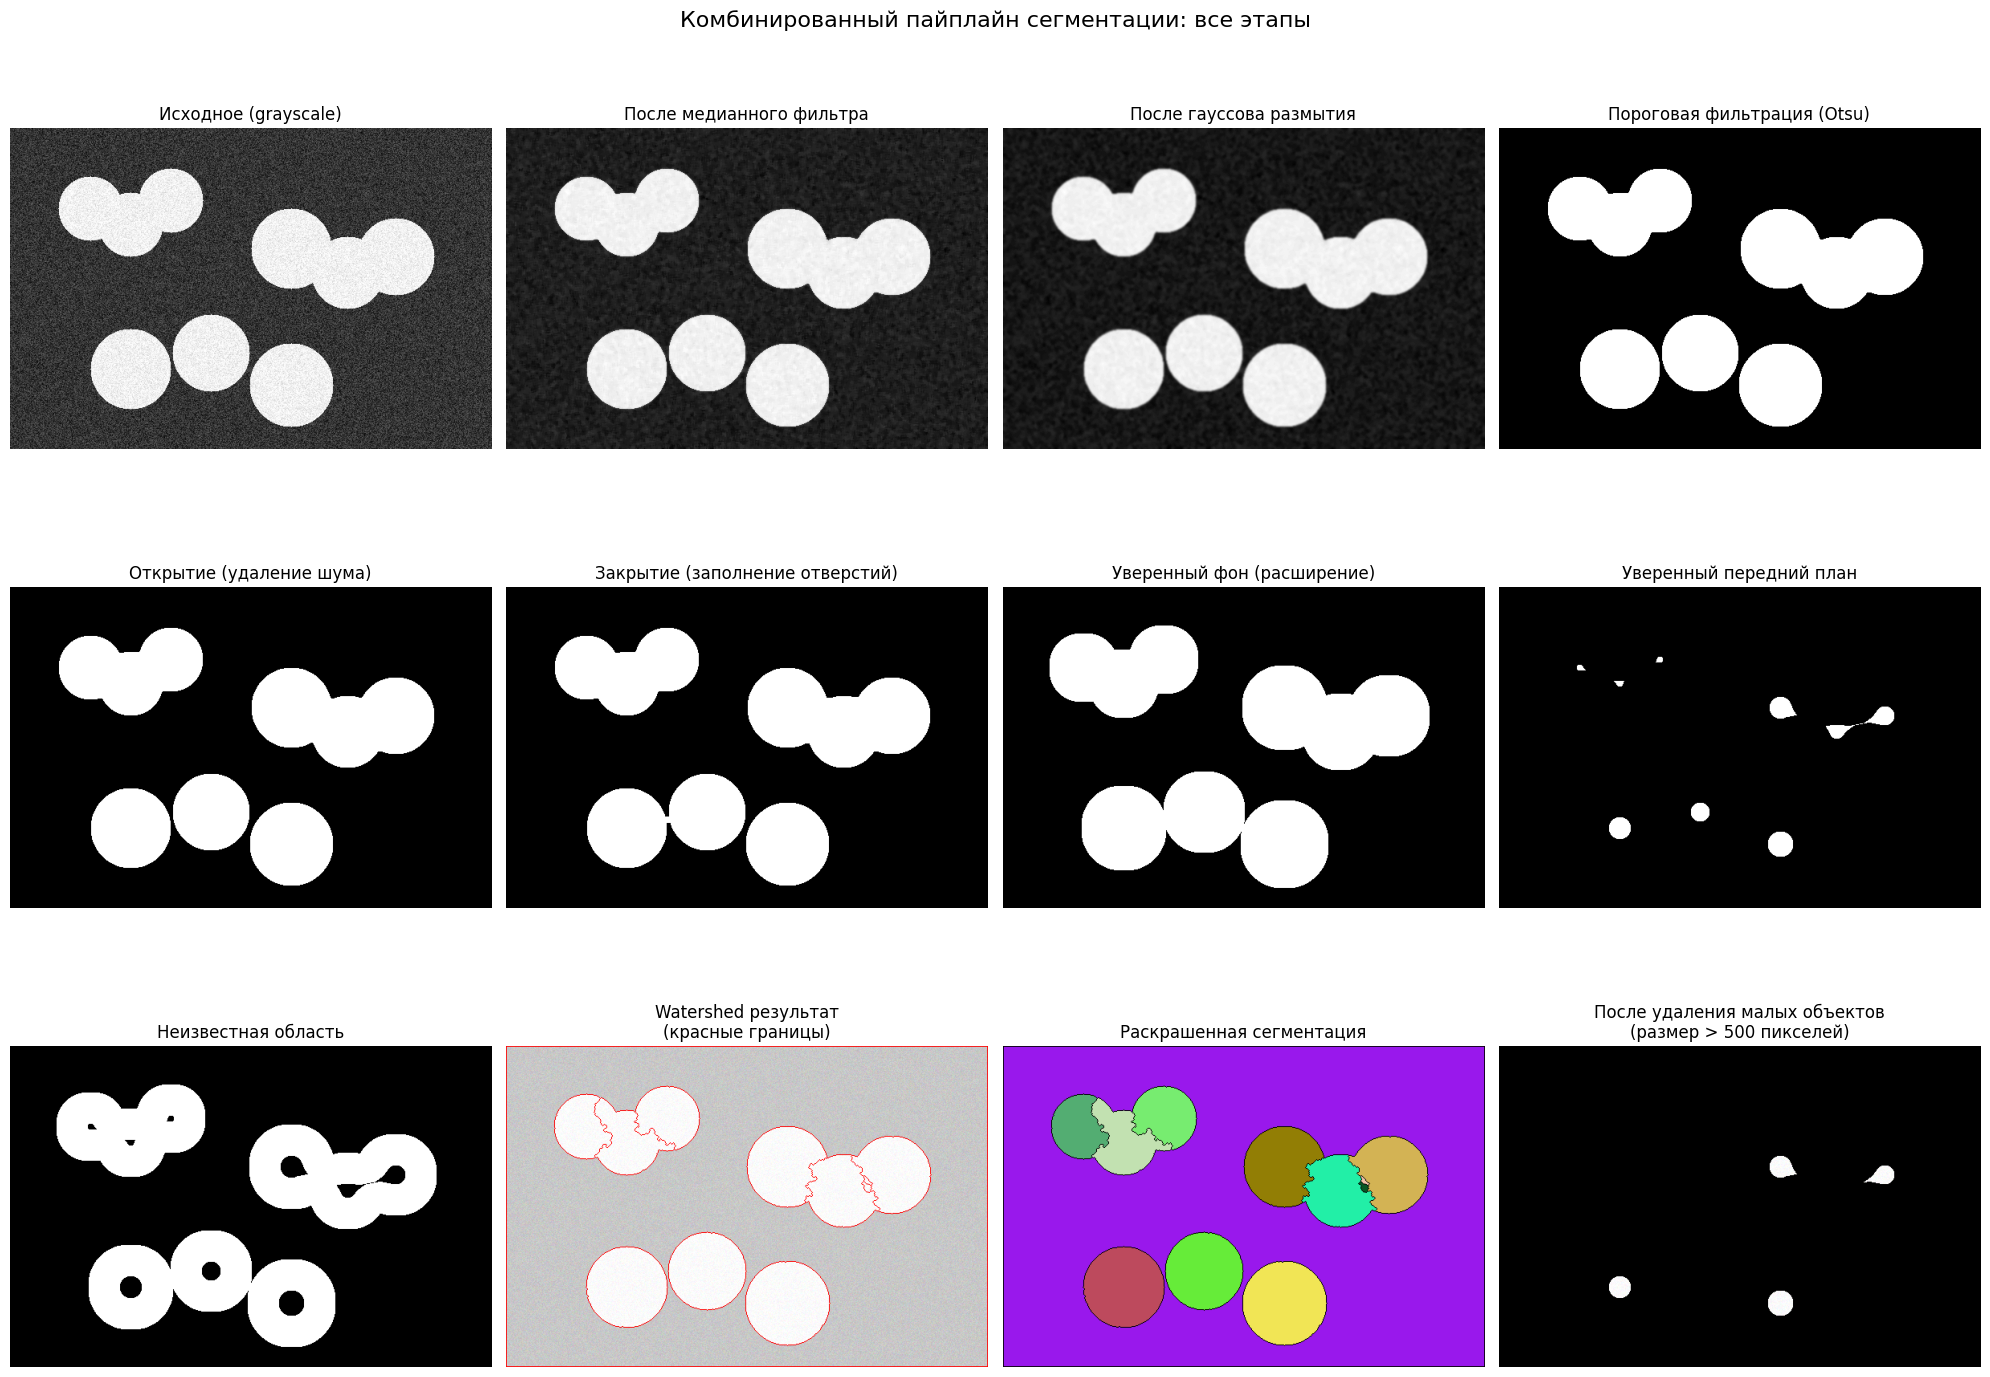

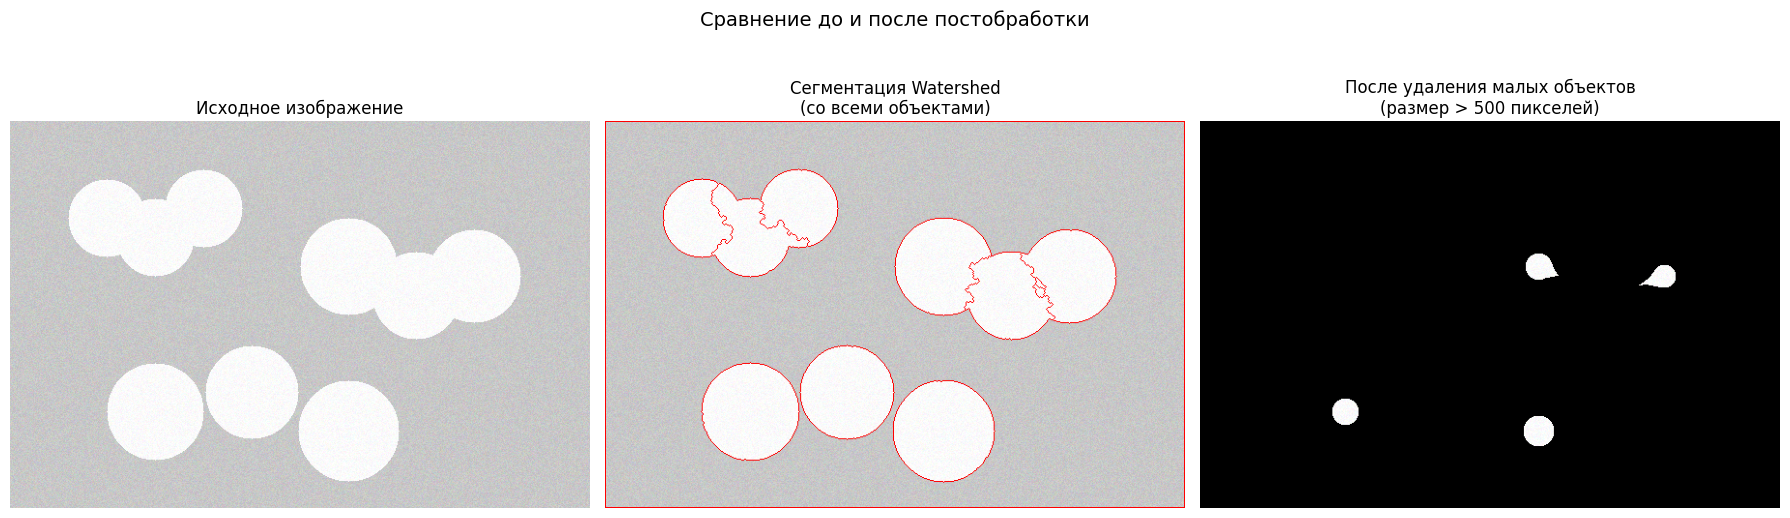


Статистика пайплайна:
  Объектов обнаружено: 11
  Объектов после фильтрации: 12
  Удалено малых объектов: -1
  Минимальный размер объекта: 500 пикселей


In [14]:
# ===============================
# ЗАДАНИЕ 3: Комбинированный пайплайн
# ===============================

def combined_segmentation_pipeline(img):

    # 1. ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА
    print("1. Предварительная обработка...")

    # Преобразуем в grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Применяем медианный фильтр для удаления шума
    filtered = cv2.medianBlur(gray, 5)

    # Применяем гауссово размытие
    blurred = cv2.GaussianBlur(filtered, (5, 5), 0)

    # 2. ПОРОГОВАЯ ФИЛЬТРАЦИЯ
    print("2. Пороговая фильтрация...")

    # Автоматическая пороговая фильтрация Otsu
    ret, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 3. МОРФОЛОГИЧЕСКИЕ ОПЕРАЦИИ
    print("3. Морфологические операции...")

    # Создаем ядро для морфологических операций
    kernel = np.ones((3, 3), np.uint8)

    # Удаление шума (открытие)
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

    # Заполнение отверстий (закрытие)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Уверенный фон (расширение)
    sure_bg = cv2.dilate(closing, kernel, iterations=3)

    # Нахождение уверенного переднего плана
    dist_transform = cv2.distanceTransform(closing, cv2.DIST_L2, 5)
    ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
    sure_fg = sure_fg.astype(np.uint8)

    # Неизвестная область
    unknown = cv2.subtract(sure_bg, sure_fg)

    # 4. WATERSHED ДЛЯ РАЗДЕЛЕНИЯ
    print("4. Watershed для разделения объектов...")

    # Маркировка меток
    ret, markers = cv2.connectedComponents(sure_fg)

    # Добавляем 1 ко всем меткам, чтобы фон был 1, а не 0
    markers = markers + 1

    # Помечаем неизвестную область как 0
    markers[unknown == 255] = 0

    # Применяем Watershed
    markers = cv2.watershed(img, markers)

    # 5. ПОСТОБРАБОТКА
    print("5. Постобработка...")

    # Создаем результат с границами
    result_with_borders = img.copy()
    result_with_borders[markers == -1] = [0, 0, 255]  # Красные границы

    # Создаем раскрашенную сегментацию
    colored_result = np.zeros_like(img)

    # Генерируем случайные цвета для каждого сегмента
    unique_markers = np.unique(markers)

    for marker in unique_markers:
        if marker > 0 and marker != -1:  # Игнорируем фон и границы
            # Генерируем случайный цвет
            color = np.random.randint(0, 255, 3).tolist()
            colored_result[markers == marker] = color

    # Удаление малых объектов (постобработка)
    print("   Удаление малых объектов...")

    # Находим все связанные компоненты
    num_labels, labels_im = cv2.connectedComponents(sure_fg)

    # Создаем маску для больших объектов
    min_object_size = 500  # Минимальный размер объекта в пикселях
    large_objects_mask = np.zeros_like(sure_fg)

    for label in range(1, num_labels):  # Пропускаем фон (0)
        component_mask = (labels_im == label).astype(np.uint8)
        component_size = np.sum(component_mask)

        if component_size > min_object_size:
            large_objects_mask = cv2.bitwise_or(large_objects_mask, component_mask)

    # Применяем маску больших объектов
    filtered_result = img.copy()
    filtered_result[large_objects_mask == 0] = 0

    # Статистика
    n_objects_before = num_labels - 1  # Минус фон
    n_objects_after = len([m for m in unique_markers if m > 0 and m != -1])

    print(f"Объектов до фильтрации: {n_objects_before}")
    print(f"Объектов после фильтрации: {n_objects_after}")
    print(f"Удалено малых объектов: {n_objects_before - n_objects_after}")

    # Визуализация всех этапов - ИСПРАВЛЕНО: убраны лишние графики
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))

    # Ряд 1: Предварительная обработка
    axes[0, 0].imshow(gray, cmap='gray')
    axes[0, 0].set_title('Исходное (grayscale)')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(filtered, cmap='gray')
    axes[0, 1].set_title('После медианного фильтра')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(blurred, cmap='gray')
    axes[0, 2].set_title('После гауссова размытия')
    axes[0, 2].axis('off')

    axes[0, 3].imshow(binary, cmap='gray')
    axes[0, 3].set_title('Пороговая фильтрация (Otsu)')
    axes[0, 3].axis('off')

    # Ряд 2: Пороговая фильтрация и морфология
    axes[1, 0].imshow(opening, cmap='gray')
    axes[1, 0].set_title('Открытие (удаление шума)')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(closing, cmap='gray')
    axes[1, 1].set_title('Закрытие (заполнение отверстий)')
    axes[1, 1].axis('off')

    axes[1, 2].imshow(sure_bg, cmap='gray')
    axes[1, 2].set_title('Уверенный фон (расширение)')
    axes[1, 2].axis('off')

    axes[1, 3].imshow(sure_fg, cmap='gray')
    axes[1, 3].set_title('Уверенный передний план')
    axes[1, 3].axis('off')

    # Ряд 3: Watershed и результаты
    axes[2, 0].imshow(unknown, cmap='gray')
    axes[2, 0].set_title('Неизвестная область')
    axes[2, 0].axis('off')

    axes[2, 1].imshow(cv2.cvtColor(result_with_borders, cv2.COLOR_BGR2RGB))
    axes[2, 1].set_title('Watershed результат\n(красные границы)')
    axes[2, 1].axis('off')

    axes[2, 2].imshow(cv2.cvtColor(colored_result, cv2.COLOR_BGR2RGB))
    axes[2, 2].set_title('Раскрашенная сегментация')
    axes[2, 2].axis('off')

    axes[2, 3].imshow(cv2.cvtColor(filtered_result, cv2.COLOR_BGR2RGB))
    axes[2, 3].set_title(f'После удаления малых объектов\n(размер > {min_object_size} пикселей)')
    axes[2, 3].axis('off')

    plt.suptitle('Комбинированный пайплайн сегментации: все этапы', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Дополнительная визуализация: сравнение до и после фильтрации
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Исходное изображение')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(result_with_borders, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Сегментация Watershed\n(со всеми объектами)')
    axes[1].axis('off')

    axes[2].imshow(cv2.cvtColor(filtered_result, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f'После удаления малых объектов\n(размер > {min_object_size} пикселей)')
    axes[2].axis('off')

    plt.suptitle('Сравнение до и после постобработки', fontsize=14)
    plt.tight_layout()
    plt.show()

    return {
        'original': img,
        'gray': gray,
        'filtered': filtered,
        'binary': binary,
        'opening': opening,
        'closing': closing,
        'sure_bg': sure_bg,
        'sure_fg': sure_fg,
        'unknown': unknown,
        'markers': markers,
        'result_with_borders': result_with_borders,
        'colored_result': colored_result,
        'filtered_result': filtered_result,
        'statistics': {
            'objects_before': n_objects_before,
            'objects_after': n_objects_after,
            'small_objects_removed': n_objects_before - n_objects_after,
            'min_object_size': min_object_size
        }
    }

# Запускаем комбинированный пайплайн

# Создаем тестовое изображение для пайплайна
pipeline_img = create_watershed_test_image()

# Применяем комбинированный пайплайн
pipeline_results = combined_segmentation_pipeline(pipeline_img)

# Вывод статистики
stats = pipeline_results['statistics']
print("\nСтатистика пайплайна:")
print(f"  Объектов обнаружено: {stats['objects_before']}")
print(f"  Объектов после фильтрации: {stats['objects_after']}")
print(f"  Удалено малых объектов: {stats['small_objects_removed']}")
print(f"  Минимальный размер объекта: {stats['min_object_size']} пикселей")